In [3]:
import os
import pandas as pd
import numpy as np
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [4]:
# Mount
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Working directory
# pwd = os.getcwd()

# Load from excel
nov23_file = '/content/drive/MyDrive/Colab Notebooks/TaedaGPT/Nov23_Allfeatures_updated_with_biomass.xlsx'
july24_file = '/content/drive/MyDrive/Colab Notebooks/TaedaGPT/July24_Allfeatures_updated_with_biomass.xlsx'
jan25_file = '/content/drive/MyDrive/Colab Notebooks/TaedaGPT/Jan25_Allfeatures_updated_with_biomass.xlsx'

# Nov23 sheets
df1 = pd.read_excel(nov23_file, sheet_name='GH_stem1')
df2 = pd.read_excel(nov23_file, sheet_name='GH_stem2')
df3 = pd.read_excel(nov23_file, sheet_name='PT_stem1')
df4 = pd.read_excel(nov23_file, sheet_name='PT_stem2')

# July24 sheets
df5 = pd.read_excel(july24_file, sheet_name='PT_stem1')
df6 = pd.read_excel(july24_file, sheet_name='PT_stem2')

# Jan25 sheets
df7 = pd.read_excel(jan25_file, sheet_name='GH_stem1')
df8 = pd.read_excel(jan25_file, sheet_name='GH_stem2')
df9 = pd.read_excel(jan25_file, sheet_name='PT_stem1')
df10 = pd.read_excel(jan25_file, sheet_name='PT_stem2')

In [6]:
# Clean Coeffs
coeff_cols = ['coefficients_one', 'Growth curve steepness', 'Growth curve midpoint time']

def fill_coefficients_by_mode(df, coeff_cols):
    for col in coeff_cols:
        # Keep 0s but fill Nan
        def fill_na(row, group_modes):
            if pd.isna(row[col]):
                plant_id = row['Plant_ID']
                mode_val = group_modes.get(plant_id, np.nan)
                return mode_val
            else:
                return row[col]

        # Fill with most frequent number
        non_zero = df[df[col].notna() & (df[col] != 0)]
        group_modes = non_zero.groupby('Plant_ID')[col].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan).to_dict()

        df[col] = df.apply(lambda row: fill_na(row, group_modes), axis=1)

    return df

# Apply
df1 = fill_coefficients_by_mode(df1, coeff_cols)
df2 = fill_coefficients_by_mode(df2, coeff_cols)
df3 = fill_coefficients_by_mode(df3, coeff_cols)
df4 = fill_coefficients_by_mode(df4, coeff_cols)
df5 = fill_coefficients_by_mode(df5, coeff_cols)
df6 = fill_coefficients_by_mode(df6, coeff_cols)
df7 = fill_coefficients_by_mode(df7, coeff_cols)
df8 = fill_coefficients_by_mode(df8, coeff_cols)
df9 = fill_coefficients_by_mode(df9, coeff_cols)
df10 = fill_coefficients_by_mode(df10, coeff_cols)

In [7]:
dfs = [df1, df2, df3, df4, df5, df6, df7, df8, df9, df10]

# Keep first plant ID
for i in range(len(dfs)):
    before = dfs[i].shape[0]
    dfs[i] = dfs[i].sort_values(by='Plant_ID')
    dfs[i] = dfs[i].drop_duplicates(subset='Plant_ID', keep='first').reset_index(drop=True)
    after = dfs[i].shape[0]
    print(f"df{i+1}: Dropped {before - after} rows when keeping first row per Plant_ID")

# delete Total_cuttings is NaN or 0
for i in range(len(dfs)):
    before = dfs[i].shape[0]
    dfs[i] = dfs[i].dropna(subset=['Total_cuttings'])
    dfs[i] = dfs[i][dfs[i]['Total_cuttings'] != 0].reset_index(drop=True)
    after = dfs[i].shape[0]
    print(f"df{i+1}: Dropped {before - after} rows with NaN or 0 in Total_cuttings")

df1: Dropped 1503 rows when keeping first row per Plant_ID
df2: Dropped 1395 rows when keeping first row per Plant_ID
df3: Dropped 1737 rows when keeping first row per Plant_ID
df4: Dropped 1638 rows when keeping first row per Plant_ID
df5: Dropped 1337 rows when keeping first row per Plant_ID
df6: Dropped 1316 rows when keeping first row per Plant_ID
df7: Dropped 679 rows when keeping first row per Plant_ID
df8: Dropped 658 rows when keeping first row per Plant_ID
df9: Dropped 1379 rows when keeping first row per Plant_ID
df10: Dropped 1386 rows when keeping first row per Plant_ID
df1: Dropped 79 rows with NaN or 0 in Total_cuttings
df2: Dropped 119 rows with NaN or 0 in Total_cuttings
df3: Dropped 35 rows with NaN or 0 in Total_cuttings
df4: Dropped 109 rows with NaN or 0 in Total_cuttings
df5: Dropped 20 rows with NaN or 0 in Total_cuttings
df6: Dropped 54 rows with NaN or 0 in Total_cuttings
df7: Dropped 41 rows with NaN or 0 in Total_cuttings
df8: Dropped 57 rows with NaN or 0 in 

In [8]:
# Keep data from first plant ID
for i in range(len(dfs)):
    before = dfs[i].shape[0]
    dfs[i] = dfs[i].sort_values(by='Plant_ID')
    dfs[i] = dfs[i].drop_duplicates(subset='Plant_ID')
    dfs[i] = dfs[i].reset_index(drop=True)
    after = dfs[i].shape[0]
    print(f"df{i+1}: First plant ID kept {after} rows，delete {before - after} rows")


df1: First plant ID kept 88 rows，delete 0 rows
df2: First plant ID kept 36 rows，delete 0 rows
df3: First plant ID kept 158 rows，delete 0 rows
df4: First plant ID kept 73 rows，delete 0 rows
df5: First plant ID kept 171 rows，delete 0 rows
df6: First plant ID kept 134 rows，delete 0 rows
df7: First plant ID kept 56 rows，delete 0 rows
df8: First plant ID kept 37 rows，delete 0 rows
df9: First plant ID kept 72 rows，delete 0 rows
df10: First plant ID kept 40 rows，delete 0 rows


In [9]:
# Overwirite
df1, df2, df3, df4, df5, df6, df7, df8, df9, df10 = dfs

In [10]:
columns_to_drop = ['Stem_cuttings_YEILD', 'Stem_cuttings_GUARD']

for df in [df1, df2, df3, df4, df5, df6, df7, df8, df9, df10]:
    df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

# Overwirite
df1, df2, df3, df4, df5, df6, df7, df8, df9, df10 = dfs

In [11]:
# convert into float
def convert_to_float(df, df_name, columns):
    for col in columns:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        else:
            print(f"⚠️ Column {col} not found in {df_name}")
    return df

# Apply to rows
columns_to_convert = ['Stem length', 'Stem diameter']


df1 = convert_to_float(df1, 'df1', columns_to_convert)
df2 = convert_to_float(df2, 'df2', columns_to_convert)
df3 = convert_to_float(df3, 'df3', columns_to_convert)
df4 = convert_to_float(df4, 'df4', columns_to_convert)
df5 = convert_to_float(df5, 'df5', columns_to_convert)
df6 = convert_to_float(df6, 'df6', columns_to_convert)
df7 = convert_to_float(df7, 'df7', columns_to_convert)
df8 = convert_to_float(df8, 'df8', columns_to_convert)
df9 = convert_to_float(df9, 'df9', columns_to_convert)
df10 = convert_to_float(df10, 'df10', columns_to_convert)

In [12]:
# Merge back to dfs
Nov23_df = pd.concat([df1, df2, df3, df4], ignore_index=True)
July24_df = pd.concat([df5, df6], ignore_index=True)
Jan25_df  = pd.concat([df7, df8, df9, df10], ignore_index=True)

GH_df = pd.concat([df1, df2, df7, df8], ignore_index=True)
PT_df = pd.concat([df3, df4, df5, df6, df9, df10], ignore_index=True)

merged_df = pd.concat([Nov23_df, July24_df, Jan25_df], ignore_index=True)
# Shape
print(f"Nov23_df shape: {Nov23_df.shape}")
print(f"July24_df shape: {July24_df.shape}")
print(f"Jan25_df shape: {Jan25_df.shape}")

print(f"GH_df shape: {GH_df.shape}")
print(f"PT_df shape: {PT_df.shape}")

Nov23_df shape: (355, 140)
July24_df shape: (305, 140)
Jan25_df shape: (205, 140)
GH_df shape: (217, 140)
PT_df shape: (648, 140)


In [13]:
# Drop features with >50% missing values
missing_percent = df.isnull().mean()
cols_to_drop = missing_percent[missing_percent > 0.5].index.tolist()

# Also drop constant columns (std = 0)
constant_cols = df.loc[:, df.nunique() <= 1].columns.tolist()

# Final list to remove
drop_cols = list(set(cols_to_drop + constant_cols))
df_filtered = df.drop(columns=drop_cols)

In [14]:
# Data cleaning function
def clean_features(df, verbose=True, plot_outliers=True):
    report = {
        'dropped_missing': [],
        'dropped_constant': [],
        'filled_median': [],
        'outlier_removed': {}
    }

    df = df.copy()

    # Drop constant columns
    for col in df.columns:
        if df[col].nunique(dropna=True) <= 1:
            df.drop(columns=col, inplace=True)
            report['dropped_constant'].append(col)

    # Handle missing value thresholds
    missing_percent = df.isnull().mean()

    # Drop >50% missing
    drop_missing = missing_percent[missing_percent > 0.5].index.tolist()
    df.drop(columns=drop_missing, inplace=True)
    report['dropped_missing'].extend(drop_missing)

    # Median fill for 30–50% missing
    fill_median = missing_percent[(missing_percent > 0.3) & (missing_percent <= 0.5)].index.tolist()
    for col in fill_median:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        report['filled_median'].append(col)

    # Remove outliers using IQR method for specific columns
    for col in ['Stem length', 'Stem diameter']:
        if col in df.columns:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 2.0 * IQR
            upper = Q3 + 2.0 * IQR

            if plot_outliers:
                # Plot before
                sns.histplot(df[col], bins=50, kde=True)
                plt.title(f"{col} before outlier removal")
                plt.show()

            before_count = df.shape[0]
            df = df[(df[col] >= lower) & (df[col] <= upper)]
            after_count = df.shape[0]
            removed = before_count - after_count
            report['outlier_removed'][col] = removed

            if plot_outliers:
                # Plot after
                sns.histplot(df[col], bins=50, kde=True)
                plt.title(f"{col} after outlier removal")
                plt.show()

    # Final report
    if verbose:
        print(f"\n--- Cleaning Finished ---")
        print(f"Dropped constant columns: {report['dropped_constant']}")
        print(f"Dropped >50% missing columns: {report['dropped_missing']}")
        print(f"Median-filled 30–50% missing columns: {report['filled_median']}")
        print(f"Outlier rows removed: {report['outlier_removed']}")
        print(f"Final shape: {df.shape}")

    return df

In [15]:
# --------------------------
# Feature selection function
# --------------------------
def filter_important_features(X, y, threshold=0.01):
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X, y)
    importances = pd.Series(rf.feature_importances_, index=X.columns)

    # Plot top 20 features
    importances.sort_values(ascending=False).head(15).plot(kind='barh', figsize=(10, 7))
    plt.title("Machine Learning Top 15 Feature Importances")
    plt.gca().invert_yaxis()
    plt.show()

    return importances[importances >= threshold].index.tolist()

# --------------------------
# Preprocessing + Training
# --------------------------
def train_model_on_dataset(df, dataset_name=''):
    print(f"\n--- {dataset_name.upper()} ---")

    # Ensure TWBM is numeric
    df['Total_cuttings'] = pd.to_numeric(df['Total_cuttings'], errors='coerce')

    # Drop rows with missing TWBM
    df = df.dropna(subset=['Total_cuttings']).copy()

    # Define target
    y = df['Total_cuttings']

    # Separate numeric and object columns
    df_numeric = df.select_dtypes(include=[np.number])
    cat_cols_to_encode = ['Genotype']  # update if needed
    df_categorical = df[cat_cols_to_encode].astype(str)

    # Drop auxiliary/leaky from numeric
    excluded = ['Total_cuttings', 'Stem_cuttings_YEILD', 'Stem_cuttings_GUARD', 'Unnamed: 0', 'coefficients_one']
    X_numeric = df_numeric.drop(columns=excluded, errors='ignore').fillna(0)

    # Drop leaky columns with >0.98 correlation to TWBM
    correlations = df_numeric.corr(numeric_only=True)['Total_cuttings'].drop('Total_cuttings')
    leaky_features = correlations[abs(correlations) > 0.98].index.tolist()
    X_numeric = X_numeric.drop(columns=leaky_features, errors='ignore')

    # One-hot encode selected categorical variables
    X_categorical = pd.get_dummies(df_categorical, dummy_na=True)

    # Combine numeric and categorical features
    X_full = pd.concat([X_numeric, X_categorical], axis=1).fillna(0)

    # # Threshold sensitivity testing
    # print("\n--- Feature importance threshold sweep ---")
    # for t in [0.02, 0.01, 0.005, 0.001]:
    #     important_cols = filter_important_features(X_full, y, threshold=t)
    #     print(f"Threshold {t:.3f} → {len(important_cols)} features selected")


    # Feature selection
    important_cols = filter_important_features(X_full, y)
    X_filtered = X_full[important_cols]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X_filtered, y, test_size=0.3, random_state=42)

    # Scale
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Models
    models = {
    # 'LinearRegression': LinearRegression(),
    # 'Ridge': Ridge(alpha=1.0),
    # 'Lasso': Lasso(alpha=0.1),
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'RandomForest': RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=200, max_depth=3, subsample=0.8, colsample_bytree=0.8, random_state=42)
}

    for name, model in models.items():
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        mae = mean_absolute_error(y_test, preds)
        r2 = r2_score(y_test, preds)
        print(f"{name} | MAE: {mae:.3f} | R2: {r2:.3f}")

        if name == "RandomForest":
            import seaborn as sns
            import matplotlib.pyplot as plt

            residuals = y_test - preds
            sns.histplot(residuals, bins=50, kde=True)
            plt.title("Residuals Distribution for Random Forest")
            plt.xlabel("Prediction Error (Actual - Predicted)")
            plt.ylabel("Frequency")
            plt.show()


--- PT DATA ---


/tmp/ipython-input-1665910281.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)


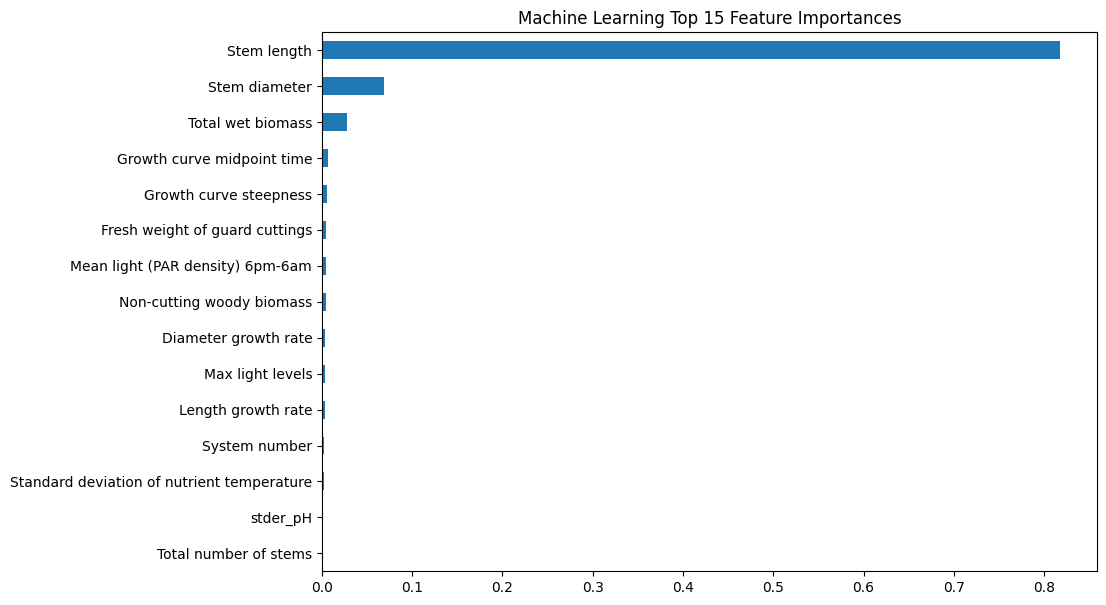

KNN | MAE: 1.166 | R2: 0.848
RandomForest | MAE: 1.106 | R2: 0.866


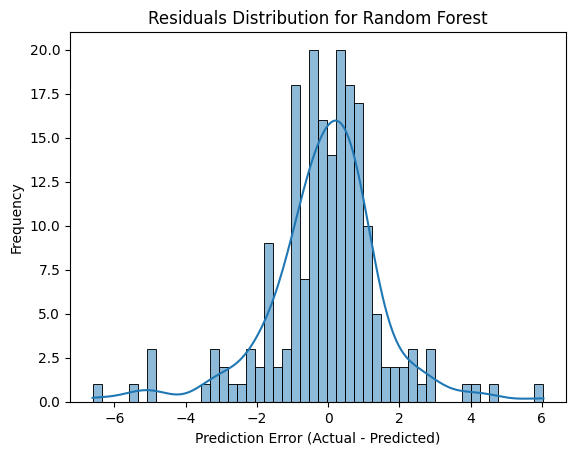

XGBoost | MAE: 1.247 | R2: 0.832

--- GH DATA ---


/tmp/ipython-input-1665910281.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)


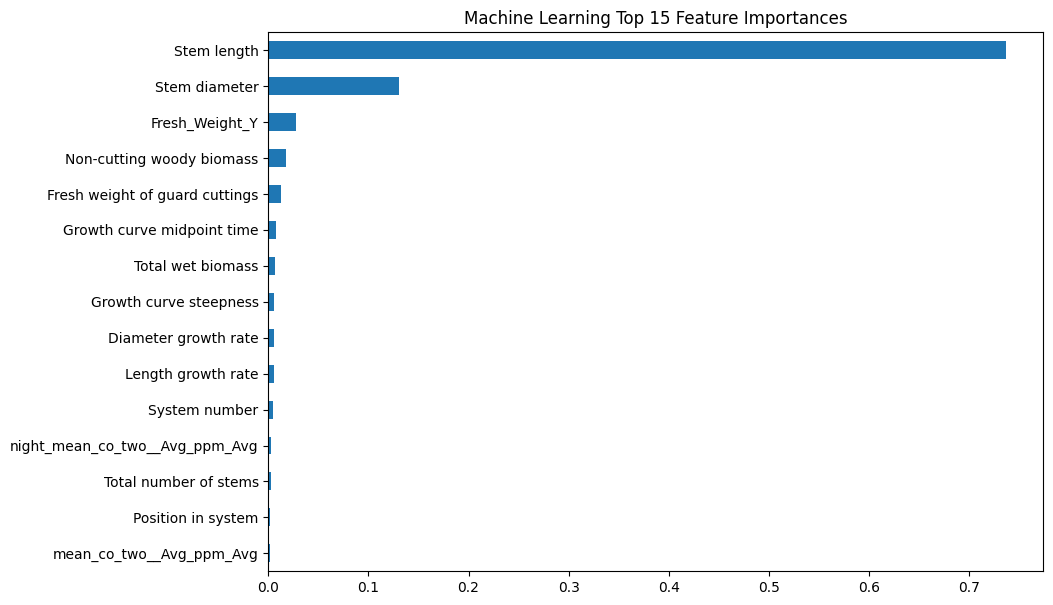

KNN | MAE: 0.861 | R2: 0.871
RandomForest | MAE: 0.722 | R2: 0.926


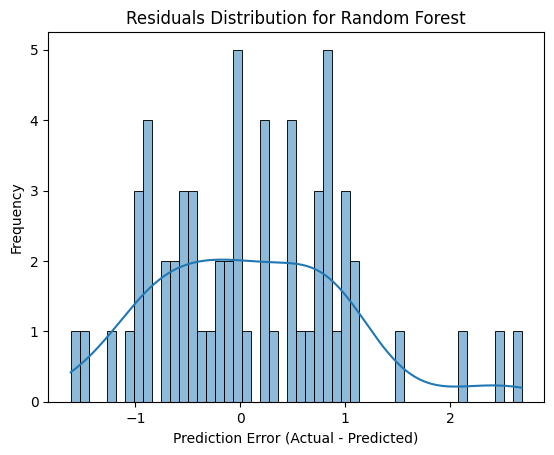

XGBoost | MAE: 0.911 | R2: 0.883

--- ALL DATA ---


/tmp/ipython-input-1665910281.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)


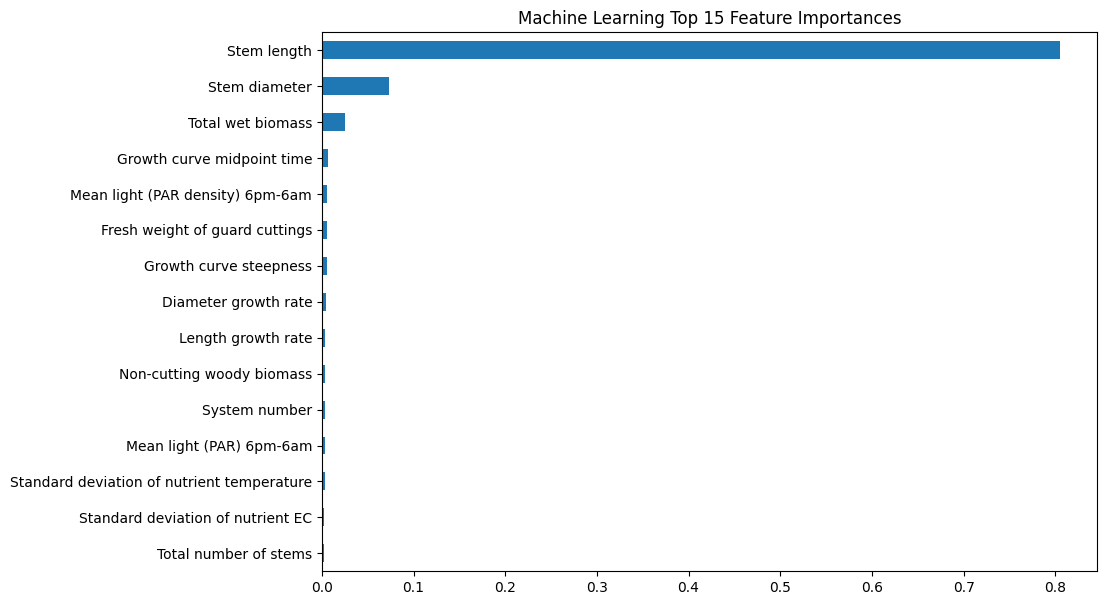

KNN | MAE: 1.116 | R2: 0.842
RandomForest | MAE: 1.049 | R2: 0.843


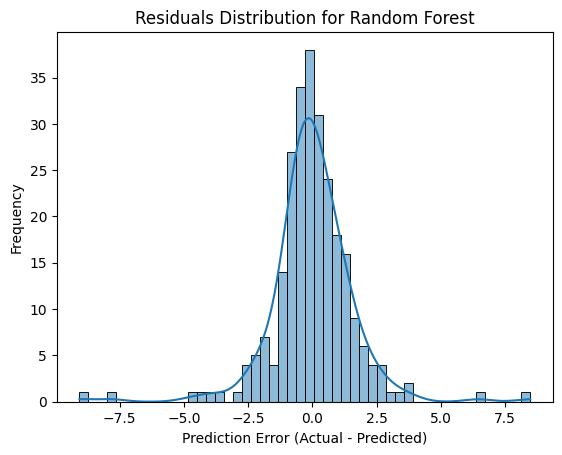

XGBoost | MAE: 1.196 | R2: 0.820


In [16]:
PT_df_cleaned = clean_features(PT_df, verbose=False, plot_outliers=False)
train_model_on_dataset(PT_df_cleaned, 'PT Data')

GH_df_cleaned = clean_features(GH_df, verbose=False, plot_outliers=False)
train_model_on_dataset(GH_df_cleaned, 'GH Data')

merged_df
merged_df_cleaned = clean_features(merged_df, verbose=False, plot_outliers=False)
train_model_on_dataset(merged_df_cleaned, 'All Data')


Models training done, GPT functions blow


--- ALL DATA ---


/tmp/ipython-input-1665910281.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)


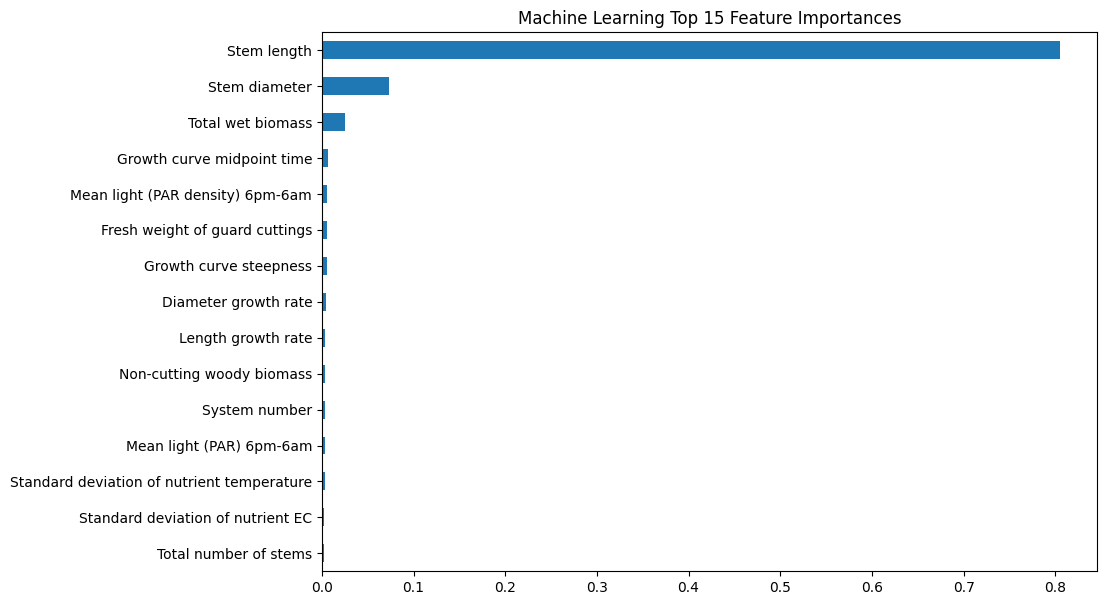

--- Model Training Complete ---

Successfully trained and captured the model.
The model expects 3 features.


In [17]:
# --- Modify this function to return the model, scaler, and columns ---
def train_model_on_dataset(df, dataset_name=''):
    print(f"\n--- {dataset_name.upper()} ---")

    # Data preparation
    df['Total_cuttings'] = pd.to_numeric(df['Total_cuttings'], errors='coerce')
    df = df.dropna(subset=['Total_cuttings']).copy()
    y = df['Total_cuttings']
    df_numeric = df.select_dtypes(include=[np.number])
    cat_cols_to_encode = ['Genotype']
    df_categorical = df[cat_cols_to_encode].astype(str)
    excluded = ['Total_cuttings', 'Stem_cuttings_YEILD', 'Stem_cuttings_GUARD', 'Unnamed: 0', 'coefficients_one']
    X_numeric = df_numeric.drop(columns=excluded, errors='ignore').fillna(0)
    correlations = df_numeric.corr(numeric_only=True)['Total_cuttings'].drop('Total_cuttings')
    leaky_features = correlations[abs(correlations) > 0.98].index.tolist()
    X_numeric = X_numeric.drop(columns=leaky_features, errors='ignore')
    X_categorical = pd.get_dummies(df_categorical, dummy_na=True)
    X_full = pd.concat([X_numeric, X_categorical], axis=1).fillna(0)

    # Feature selection
    important_cols = filter_important_features(X_full, y, threshold=0.01) # Using threshold from your function
    X_filtered = X_full[important_cols]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X_filtered, y, test_size=0.3, random_state=42)

    # Scale
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # --- Train the final RandomForest model on the FULL filtered dataset ---
    # This ensures the model uses all available data for the best performance
    final_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
    final_model.fit(scaler.fit_transform(X_filtered), y) # Fit on all filtered data

    print("--- Model Training Complete ---")
    # ... (the rest of your evaluation code can remain for testing)

    # --- RETURN THE TRAINED OBJECTS ---
    return final_model, scaler, important_cols

# --- Run the training for your best dataset ('All Data') and capture the results ---
merged_df_cleaned = clean_features(merged_df, verbose=False, plot_outliers=False)
rf_model, scaler, important_columns = train_model_on_dataset(merged_df_cleaned, 'All Data')

print(f"\nSuccessfully trained and captured the model.")
print(f"The model expects {len(important_columns)} features.")

In [18]:
import joblib

# Save the RandomForest model
joblib.dump(rf_model, 'random_forest_model.pkl')

# Save the StandardScaler
joblib.dump(scaler, 'scaler.pkl')

# Save the list of important feature columns
joblib.dump(important_columns, 'important_columns.pkl')

print("Model, scaler, and column list have been successfully saved to files.")

Model, scaler, and column list have been successfully saved to files.


In [19]:
import pandas as pd
import joblib

# Load the necessary objects from your saved files
loaded_model = joblib.load('random_forest_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')
loaded_columns = joblib.load('important_columns.pkl')

def predict_cuttings(features_dict):
    """
    Predicts the total cuttings from a dictionary of input features.
    It loads the trained model, scaler, and column list to make a prediction.
    """
    # Create a DataFrame from the input dictionary
    input_df = pd.DataFrame([features_dict])

    # Ensure the dataframe has the exact same columns in the same order as the training data.
    # This step is crucial for the model to work correctly. It will add any missing
    # columns from your feature list and fill them with a default value of 0.
    input_df = input_df.reindex(columns=loaded_columns, fill_value=0)

    # Scale the features using the loaded scaler
    input_scaled = loaded_scaler.transform(input_df)

    # Make the prediction using the loaded model
    prediction = loaded_model.predict(input_scaled)

    # Return the single predicted value
    return prediction[0]

In [20]:
# --- Create a sample dictionary with 3 important features ---
sample_features = {
    'Feature_Name_1': 20.5,
    'Feature_Name_2': 5.2,
    'Feature_Name_3': 1.0
}

# Get a prediction
predicted_value = predict_cuttings(sample_features)

# print(f"\nTest Prediction Successful!")
print(f"Predicted Cuttings for the sample features: {predicted_value:.2f}")

Predicted Cuttings for the sample features: 6.24


In [21]:
import pandas as pd
import joblib
import google.generativeai as genai

# --- 1. Configure your API Key ---
from google.colab import userdata
try:
    GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
    genai.configure(api_key=GOOGLE_API_KEY)
except userdata.SecretNotFoundError as e:
    print(f"Secret not found: {e}. Please make sure you have stored your GOOGLE_API_KEY in Colab secrets.")
except Exception as e:
    print(f"An error occurred: {e}")


# --- 2. Load your saved model, scaler, and columns ---
loaded_model = joblib.load('random_forest_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')
loaded_columns = joblib.load('important_columns.pkl')


# --- 3. Define the prediction function ---
# The function will now return a simple float value.
def predict_cuttings(stem_diameter: float, stem_length: float, total_wet_biomass: float):
    """Predicts the total number of cuttings from a plant based on its features."""

    features_dict = {
        "Stem diameter": stem_diameter,
        "Stem length": stem_length,
        "Total wet biomass": total_wet_biomass
    }

    input_df = pd.DataFrame([features_dict])
    input_df = input_df.reindex(columns=loaded_columns, fill_value=0)
    input_scaled = loaded_scaler.transform(input_df)
    prediction = loaded_model.predict(input_scaled)

    return prediction[0]


# --- 4. Define the tool for the LLM using the standard Dictionary format ---
predict_cuttings_tool = {
    "name": "predict_cuttings",
    "description": "Predicts the total number of cuttings from a plant based on its features.",
    "parameters": {
        "type": "OBJECT",
        "properties": {
            "stem_diameter": {
                "type": "NUMBER",
                "description": "The diameter of the stem in millimeters."
            },
            "stem_length": {
                "type": "NUMBER",
                "description": "The length of the stem in centimeters."
            },
            "total_wet_biomass": {
                "type": "NUMBER",
                "description": "The total wet biomass of the plant in grams."
            }
        },
        "required": ["stem_diameter", "stem_length", "total_wet_biomass"]
    }
}

# --- 5. Initialize the model ---
llm_model = genai.GenerativeModel(
    model_name='gemini-1.5-flash-latest',
    tools=[predict_cuttings_tool]
)

# --- 6. Send a single prompt to the model to get the function call ---
prompt = "Can you predict the total cuttings for a plant with a stem length of 232 cm, a stem diameter of 11.8 mm, and a total wet biomass of 229.32 grams?"

print(f"User Prompt: {prompt}\n")

response = llm_model.generate_content(prompt)
function_call = response.candidates[0].content.parts[0].function_call

# --- 7. Execute the function and print the final result ---
if function_call.name == 'predict_cuttings':
    function_args = {key: value for key, value in function_call.args.items()}
    print(f"LLM identified function arguments: {function_args}\n")

    # Call your local Python function with the extracted arguments
    prediction_result = predict_cuttings(**function_args)

    # Format the final answer directly in your code
    print("--- Final Answer ---")
    print(f"Based on the provided features, the predicted number of total cuttings is {prediction_result:.2f}.")
else:
    print("The model did not return a function call. Please check the prompt or tool definition.")

User Prompt: Can you predict the total cuttings for a plant with a stem length of 232 cm, a stem diameter of 11.8 mm, and a total wet biomass of 229.32 grams?



NotFound: 404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-1.5-flash-latest:generateContent?%24alt=json%3Benum-encoding%3Dint: models/gemini-1.5-flash-latest is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.

In [ ]:
import requests
import json

# --- Your Configuration ---
ORG_ID = "4c6e04a0-56d7-11ee-aaba-85f1b2168e5a"
API_HEADERS = {
    "Authorization": "ed_441n4chuadeat3tfupev6a7foix0np88ipo839sp4scasm97yl49r9cn5ikanc0c"
}

# --- API Request ---
device_list_url = f"https://api.edenic.io/api/v1/device/{ORG_ID}"

try:
    print("Requesting device list from the API...")
    response = requests.get(device_list_url, headers=API_HEADERS, timeout=15)
    response.raise_for_status()  # This will raise an error for bad responses

    devices = response.json()

    print("\n--- Available Devices ---")
    for device in devices:
        # This handles cases where the key exists but the value is null/None
        device_label = device.get("label") or "No Label Found"
        device_id = device.get("id") or "No ID Found"

        print(f"Label: {device_label:<25} | ID: {device_id}")

except requests.exceptions.RequestException as e:
    print(f"An error occurred: {e}")

BlueLab

In [ ]:
import os
import time
import requests
import pandas as pd
import json

# LLM and Tool setup
import google.generativeai as genai
from google.colab import userdata
from google.ai import generativelanguage as glm

# --- 1. CONFIGURATION ---
ORG_ID = "4c6e04a0-56d7-11ee-aaba-85f1b2168e5a"
API_HEADERS = {
    "Authorization": "ed_441n4chuadeat3tfupev6a7foix0np88ipo839sp4scasm97yl49r9cn5ikanc0c"
}
try:
    GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
    genai.configure(api_key=GOOGLE_API_KEY)
    print("Google API Key configured successfully.")
except Exception as e:
    print(f"Error configuring key: {e}")


# --- 2. TOOL FUNCTION DEFINITIONS ---

def list_devices():
    """Lists all available Bluelab devices with their labels and unique IDs."""
    print("--> Agent is calling the 'list_devices' tool...")
    device_url = f"https://api.edenic.io/api/v1/device/{ORG_ID}"
    try:
        resp = requests.get(device_url, headers=API_HEADERS, timeout=15)
        resp.raise_for_status()
        devices = resp.json()
        filtered_devices = [
            {"label": dev.get("label") or "No Label", "id": dev.get("id")}
            for dev in devices if dev.get("label") and dev.get("label") not in {"iuvx", "jk59", "jgzh", "jap9"}
        ]
        return {"devices": filtered_devices}
    except requests.exceptions.RequestException as e:
        return {"error": str(e)}

def get_device_telemetry(device_id: str):
    """Fetches a summary of the latest telemetry data for a specific device ID."""
    print(f"--> Agent is calling 'get_device_telemetry' for ID starting with: {device_id[:10]}...")

    end_ts = int(time.time() * 1000)
    start_ts = end_ts - (7 * 24 * 60 * 60 * 1000)

    telemetry_url = f"https://api.edenic.io/api/v1/telemetry/{device_id}"
    params = { "keys": "temperature,electrical_conductivity,ph", "startTs": start_ts, "endTs": end_ts, "interval": 86400000, "agg": "AVG" }

    try:
        r = requests.get(telemetry_url, headers=API_HEADERS, params=params, timeout=30)
        r.raise_for_status()
        data = r.json()

        if "temperature" not in data or not data["temperature"]:
            return {"message": "No data found for this device in the last 7 days."}

        rows = [{"timestamp": pd.to_datetime(int(item["ts"]), unit="ms"),
                 "temperature": float(item["value"])} for item in data.get("temperature", [])]
        df = pd.DataFrame(rows).set_index("timestamp")

        for key in ["electrical_conductivity", "ph"]:
            if key in data and data[key]:
                key_df = pd.DataFrame([{"timestamp": pd.to_datetime(int(i["ts"]), unit="ms"), key: float(i["value"])} for i in data[key]]).set_index("timestamp")
                df = df.join(key_df, how="outer")

        return {"telemetry_summary": json.loads(df.describe().to_json())}

    except requests.exceptions.RequestException as e:
        return {"error": str(e)}


# --- 3. EXPLICIT TOOL SCHEMA DEFINITION ---

# Define the tools manually as a dictionary to ensure correct parsing
tools = [
    {
        "name": "list_devices",
        "description": "Lists all available Bluelab devices with their labels and unique IDs. Use this to find the correct device_id for a given device name.",
        "parameters": {"type": "OBJECT", "properties": {}}
    },
    {
        "name": "get_device_telemetry",
        "description": "Fetches a summary of the latest telemetry data (temperature, pH, etc.) for a specific device ID over the last 7 days.",
        "parameters": {
            "type": "OBJECT",
            "properties": {
                "device_id": {"type": "STRING", "description": "The unique ID of the device."}
            },
            "required": ["device_id"]
        }
    }
]


# --- 4. MAIN CHATBOT LOGIC ---

def run_bluelab_assistant():
    system_instruction = """
    You are a helpful assistant for the Bluelab API. Your goal is to answer questions about device status.
    To do this, you must follow a two-step process:
    1. If the user asks about a device by name (e.g., 'unit 1'), you must first use the `list_devices` tool to find its corresponding ID.
    2. Once you have the correct ID, you must use the `get_device_telemetry` tool to get the data for that device.
    Finally, summarize the data to answer the user's question. Do not ask the user for the ID.
    """

    model = genai.GenerativeModel(
        model_name='gemini-1.5-flash-latest',
        tools=tools, # Use the manually defined tool schema
        system_instruction=system_instruction
    )

    chat = model.start_chat()
    print("\nTaeda Assistant is ready. Ask a question (e.g., 'How's PT_Block 1 doing?') or type 'quit' to exit.")

    while True:
        prompt = input("You: ")
        if prompt.lower() == 'quit':
            print("Exiting assistant. Goodbye!")
            break
        if not prompt:
            continue

        response = chat.send_message(prompt)

        while response.candidates[0].content.parts[0].function_call.name:
            function_call = response.candidates[0].content.parts[0].function_call

            if function_call.name == "list_devices":
                api_result = list_devices()
            elif function_call.name == "get_device_telemetry":
                args = {key: value for key, value in function_call.args.items()}
                api_result = get_device_telemetry(device_id=args["device_id"])
            else:
                api_result = {"error": f"Unknown function call: {function_call.name}"}

            response = chat.send_message(
                glm.Part(function_response=glm.FunctionResponse(
                    name=function_call.name,
                    response=api_result,
                ))
            )

        print(f"\nAssistant: {response.text}\n")

if __name__ == "__main__":
    run_bluelab_assistant()

In [ ]:
!pip install rich
from rich.console import Console
from rich.panel import Panel

In [ ]:
import os
import time
import requests
import pandas as pd
import json
from datetime import datetime, timedelta

# LLM and Tool setup
import google.generativeai as genai
from google.colab import userdata
from google.ai import generativelanguage as glm
from rich.console import Console

# --- 1. CONFIGURATION ---
ORG_ID = "4c6e04a0-56d7-11ee-aaba-85f1b2168e5a"
API_HEADERS = {
    "Authorization": "ed_441n4chuadeat3tfupev6a7foix0np88ipo839sp4scasm97yl49r9cn5ikanc0c"
}
try:
    GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
    genai.configure(api_key=GOOGLE_API_KEY)
    print("Google API Key configured successfully.")
except Exception as e:
    print(f"Error configuring key: {e}")


# --- 2. CONSOLIDATED TOOL FUNCTIONS ---

def list_devices():
    """Lists all available Taeda devices with their labels and unique IDs."""
    print("--> Agent is using the 'list_devices' tool...")
    device_url = f"https://api.edenic.io/api/v1/device/{ORG_ID}"
    try:
        resp = requests.get(device_url, headers=API_HEADERS, timeout=15)
        resp.raise_for_status()
        devices = resp.json()
        filtered_devices = [
            {"label": dev.get("label") or "No Label", "id": dev.get("id")}
            for dev in devices
            if dev.get("label") and dev.get("label") not in {"iuvx", "jk59", "jgzh", "jap9"}
        ]
        return {"devices": filtered_devices}
    except requests.exceptions.RequestException as e:
        return {"error": str(e)}

def get_device_telemetry(device_id: str, days: int = 0):
    """
    Fetches telemetry data for a specific device ID.
    - If 'days' is 0, it gets the most recent live data from the last hour.
    - If 'days' is greater than 0 (e.g., 7 or 30), it gets the average data for that many past days.
    """
    print(f"--> Agent is calling 'get_device_telemetry' for ID: {device_id[:10]}...")

    end_ts = int(time.time() * 1000)

    if days == 0:
        # LIVE DATA MODE
        print(f"--> Getting live data for the last hour.")
        start_ts = end_ts - 3600000 # 1 hour ago
        params = {"keys": "temperature,electrical_conductivity,ph", "startTs": start_ts, "endTs": end_ts, "agg": "NONE", "limit": "1"}
    else:
        # HISTORICAL SUMMARY MODE
        print(f"--> Getting summary for the last {days} days.")
        start_ts = end_ts - (days * 24 * 60 * 60 * 1000)
        # The API requires a larger interval for longer ranges. A 1-day interval is a safe bet.
        interval = 86400000 # 1 day in milliseconds
        params = {"keys": "temperature,electrical_conductivity,ph", "startTs": start_ts, "endTs": end_ts, "interval": interval, "agg": "AVG"}

    telemetry_url = f"https://api.edenic.io/api/v1/telemetry/{device_id}"

    try:
        r = requests.get(telemetry_url, headers=API_HEADERS, params=params, timeout=30)
        r.raise_for_status()
        data = r.json()

        if not data or not any(data.get(key) for key in ["temperature", "electrical_conductivity", "ph"]):
            return {"message": "No data found for this device in the specified time range."}

        # Process the response differently for live vs. summary
        if days == 0:
             # This is for live data, we expect one result
             summary = {
                "temperature": f"{float(data['temperature'][0]['value']):.2f}",
                "ph": f"{float(data['ph'][0]['value']):.2f}",
                "electrical_conductivity": f"{float(data['electrical_conductivity'][0]['value']):.2f}",
                "timestamp": pd.to_datetime(int(data['temperature'][0]['ts']), unit='ms').strftime('%Y-%m-%d %H:%M')
            }
        else:
            # This is for historical average
            summary = {
                "average_temperature": f"{pd.Series([float(item['value']) for item in data.get('temperature', [])]).mean():.2f}",
                "average_ph": f"{pd.Series([float(item['value']) for item in data.get('ph', [])]).mean():.2f}",
                "average_ec": f"{pd.Series([float(item['value']) for item in data.get('electrical_conductivity', [])]).mean():.2f}"
            }

        return {"data": summary}

    except requests.exceptions.RequestException as e:
        return {"error": str(e)}

# --- 3. EXPLICIT TOOL SCHEMA DEFINITION ---
tools = [
    {"name": "list_devices", "description": "Lists all available Taeda devices with their labels and unique IDs.", "parameters": {"type": "OBJECT", "properties": {}}},
    {"name": "get_device_telemetry", "description": "Fetches telemetry data for a specific device ID over a specific number of past days.",
     "parameters": {"type": "OBJECT", "properties": {
         "device_id": {"type": "STRING", "description": "The unique ID of the device to query."},
         "days": {"type": "NUMBER", "description": "The number of past days to get data for. Use 0 for live/current data. Use 7 for a weekly summary."}},
      "required": ["device_id"]}}
]

# --- 4. MAIN CHATBOT LOGIC ---
def run_taeda_assistant():
    console = Console()
    system_instruction = """
    You are Taeda Assistant. Your goal is to answer questions about device status.
    1. First, you must always use the `list_devices` tool to find the correct device ID for the user's query.
    2. After you have the ID, you must use the `get_device_telemetry` tool.
    3. If the user asks for 'live', 'current', 'now', or 'today's' data, call the tool with the `days` parameter set to 0.
    4. If the user asks for a summary over a number of days (e.g., 'past 7 days', 'last week'), call the tool with the `days` parameter set to 7. For a month, use 30.
    5. Summarize the data returned from the tool to answer the user's question. Do not ask the user for an ID.
    """

    model = genai.GenerativeModel(model_name='gemini-1.5-flash-latest', tools=tools, system_instruction=system_instruction)
    chat = model.start_chat()
    console.print("\n[bold cyan]Taeda Assistant is ready.[/bold cyan] Ask a question or type 'quit' to exit.")

    while True:
        prompt = input("You: ")
        if prompt.lower() == 'quit':
            break
        if not prompt:
            continue

        response = chat.send_message(prompt)

        while response.candidates[0].content.parts[0].function_call.name:
            function_call = response.candidates[0].content.parts[0].function_call

            args = {key: value for key, value in function_call.args.items()}

            if function_call.name == "list_devices":
                api_result = list_devices()
            else: # Catches get_device_telemetry
                api_result = get_device_telemetry(**args)

            response = chat.send_message(
                glm.Part(function_response=glm.FunctionResponse(name=function_call.name, response=api_result))
            )

        console.print(
            Panel(
                response.text,
                title="[bold green]🪴 Taeda Assistant[/bold green]",
                border_style="green",
                padding=(1, 2)
            )
        )
        console.print()


if __name__ == "__main__":
    run_taeda_assistant()